# $\color{cyan}{\text{Imports and Setup}}$

## $\color{yellow}{\text{Imports}}$

In [54]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import plotly.graph_objects as go
import plotly.colors as pc
from scipy.optimize import brentq

## $\color{yellow}{\text{Setup}}$

In [55]:
# Show all dataframe columns
pd.set_option('display.max_columns', None)

### $\color{gold}{\text{Data Loading}}$

In [56]:
file_path = 'BernData'

bern_data = {}

for subfolder in os.listdir(file_path):
    subfolder_path = os.path.join(file_path, subfolder)

    if os.path.isdir(subfolder_path):
        bern_data[subfolder] = {}

        for filename in os.listdir(subfolder_path):
            file_path2 = os.path.join(subfolder_path, filename)

            if not os.path.isfile(file_path2):
                continue

            name, ext = os.path.splitext(filename)

            if ext.lower() == '.csv':
                df = pd.read_csv(file_path2)

            elif ext.lower() == '.parquet':
                df = pd.read_parquet(file_path2)

                for col in df.columns:

                    df[col] = pd.to_numeric(df[col], errors='coerce')
            else:
                continue

            bern_data[subfolder][name] = df

# $\color{orange}{\text{PEL}}$

## $\color{yellow}{\text{Sensorgram}}$

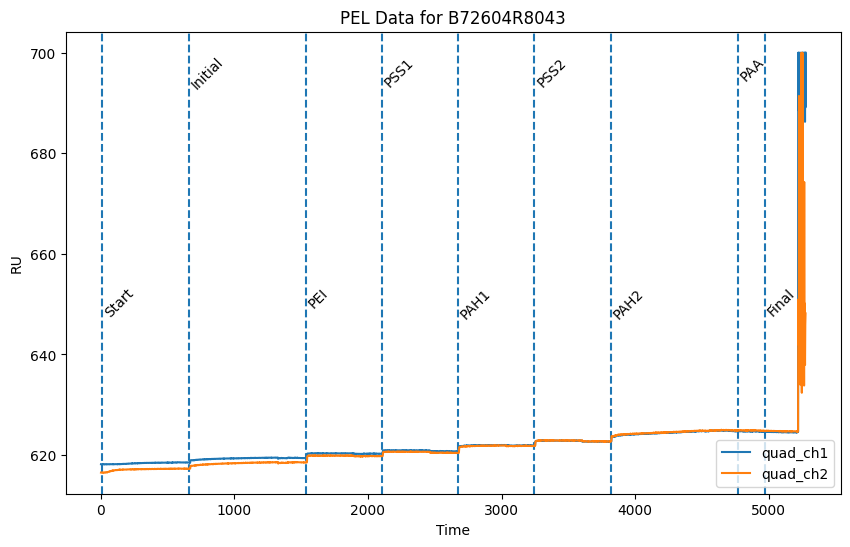

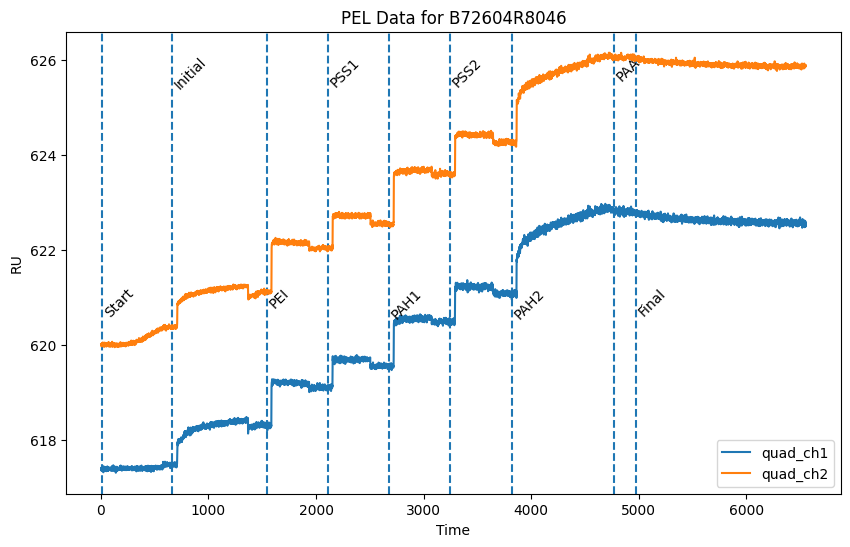

In [57]:
for chip_id, data in bern_data.items():

    for file_name, df in data.items():

        if chip_id in file_name:

            time_col = df.columns[0]
            channels = df.columns.tolist()[1:]

            flag_data = bern_data[chip_id]['flags']
            time_cols = pd.unique(flag_data.columns)[1:]
            times = flag_data[time_cols].iloc[0]

            fig, ax = plt.subplots(figsize=(10, 6))
                
            for t, label, i in zip(times, time_cols, range(len(times))):
                ax.axvline(x=t, linestyle='--')
                y_pos = 0.95 if i % 2 != 0 else 0.45
                ax.text(t, y_pos, label, rotation=45, transform=ax.get_xaxis_transform(), verticalalignment='top')
        
            for ch in channels:
                ax.plot(df[time_col], df[ch], label=ch)
        
            ax.set_title(f'PEL Data for {chip_id}')
            ax.set_xlabel('Time')
            ax.set_ylabel('RU')
            ax.legend()
            plt.show()

            break

# $\color{orange}{\text{Standard Curves}}$

## $\color{yellow}{\text{Parameter Logistic Equations}}$

In [58]:
def five_pl(x, bottom, top, ec50, hill, asym):
    return top + (bottom - top) / (1 + (x / ec50)**(hill))**asym

In [59]:
def four_pl(x, bottom, top, ec50, hill):
    return top + (bottom - top) / (1 + (x / ec50)**(hill))

## $\color{yellow}{\text{Individual}}$

In [60]:
def parse_values(s):
    
    sep = '|' if '|' in str(s) else ','
    return [float(v) for v in str(s).split(sep)]

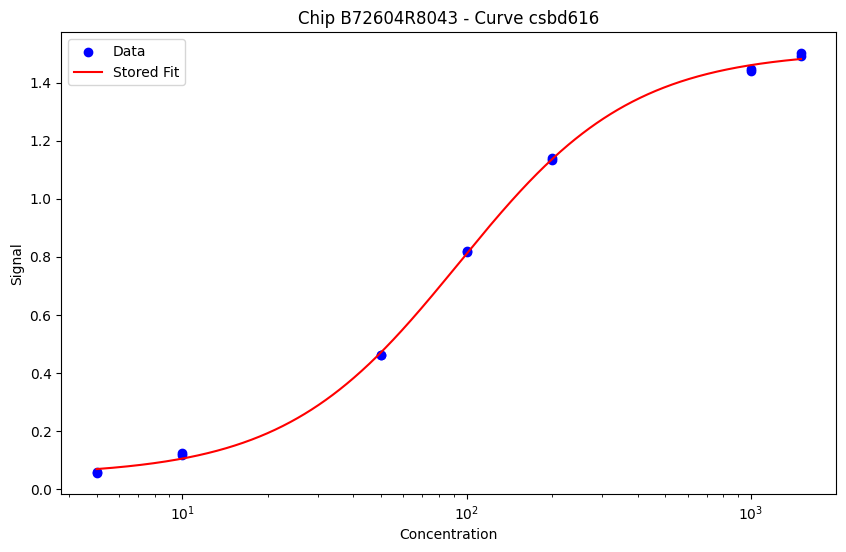

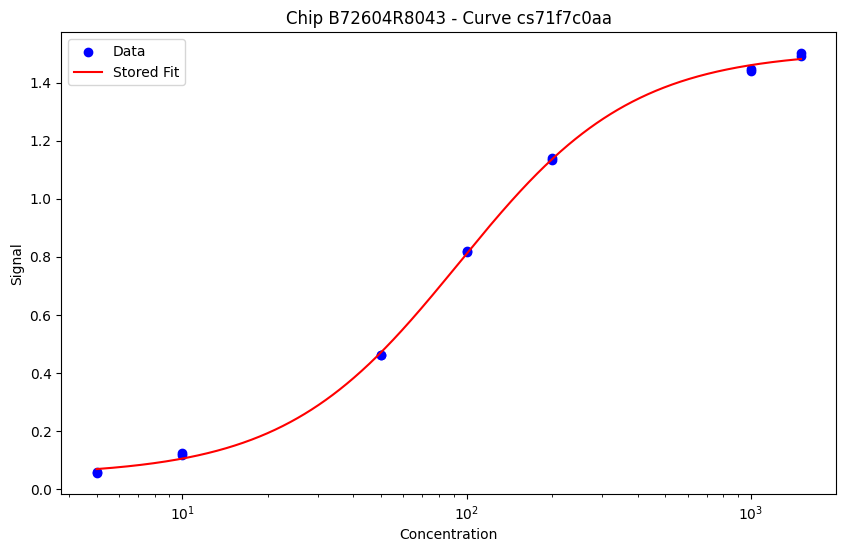

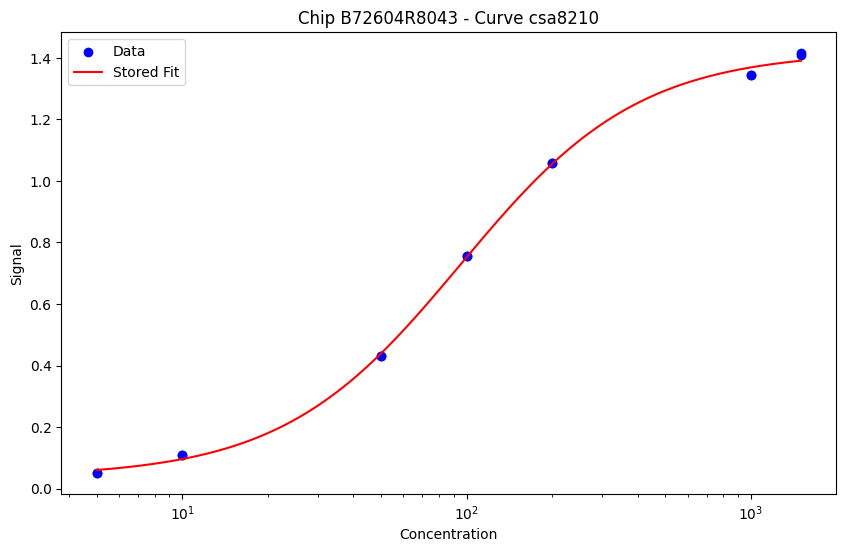

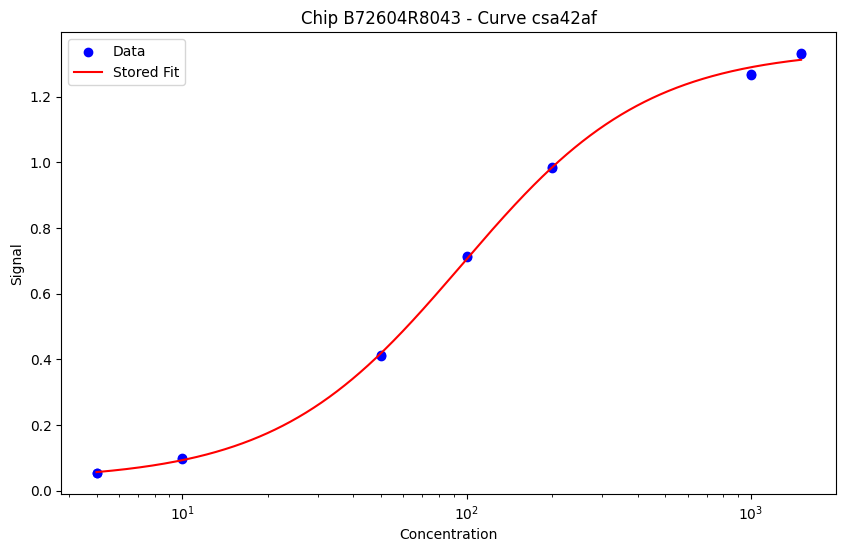

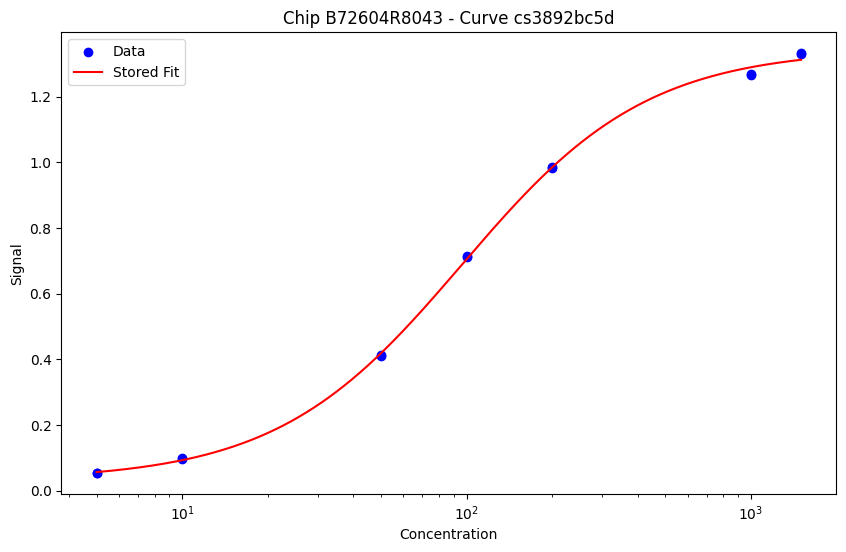

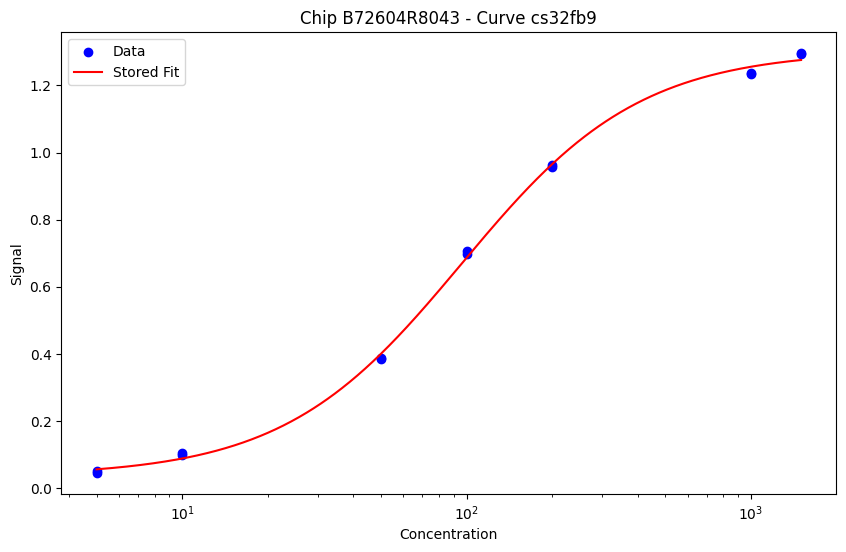

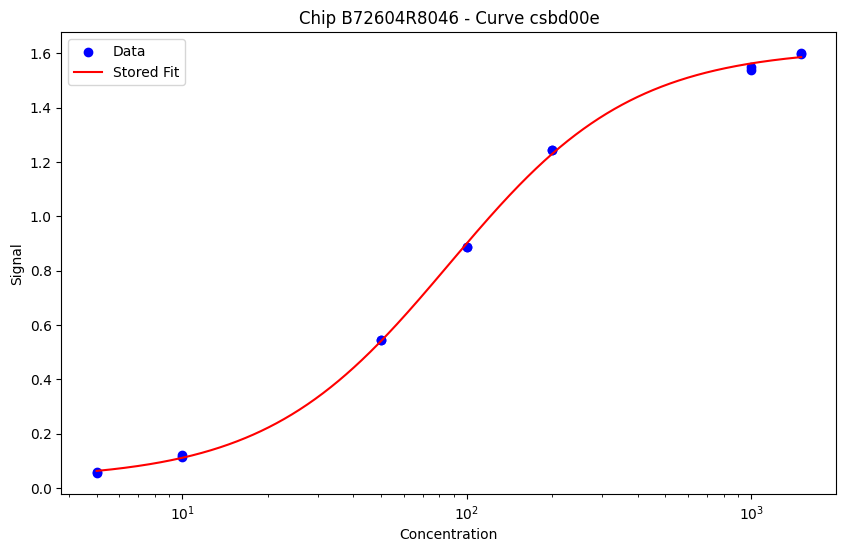

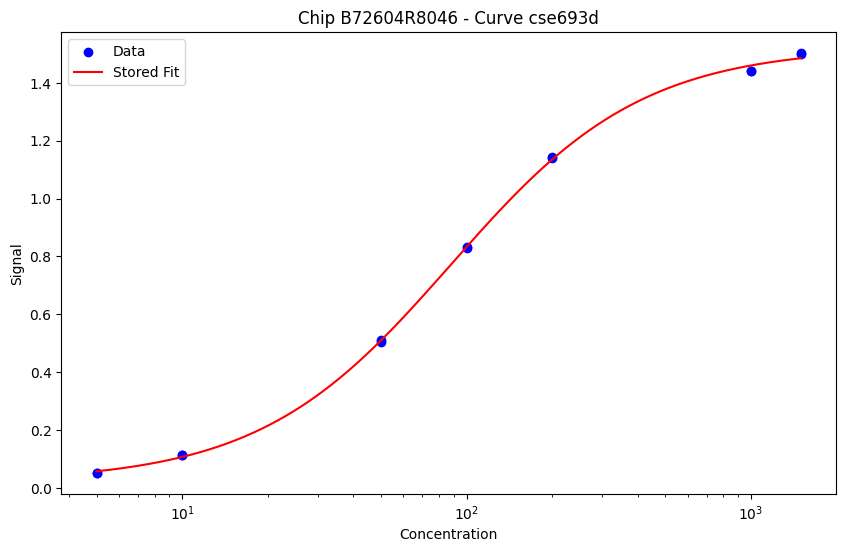

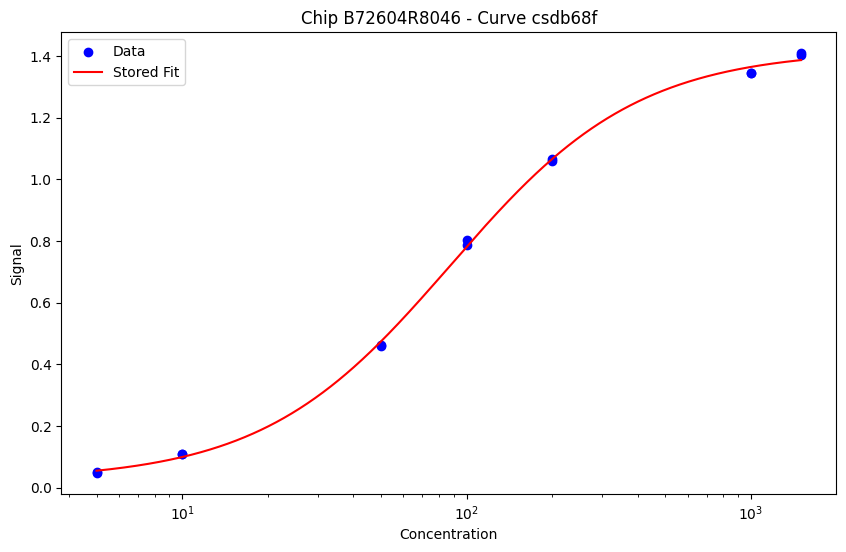

In [61]:
for chip_id, data in bern_data.items():

    for file_name, df in data.items():

        if 'standard' in file_name:
            
            for row in df.itertuples():
    
                x = parse_values(row.x_csv)
                y = parse_values(row.y_csv)
    
                x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 1000)
    
                if row.fit_model == '5PL':
                    y_fit = five_pl(x_fit, row.a, row.d, row.c, row.b, row.e)
                else:
                    y_fit = four_pl(x_fit, row.a, row.d, row.c, row.b)
    
                plt.figure(figsize=(10, 6))
                plt.scatter(x, y, color='blue', label='Data')
                plt.plot(x_fit, y_fit, color='red', label='Stored Fit')
    
                plt.xscale('log')
                plt.title(f'Chip {chip_id} - Curve {row.standard_curve_uuid}')
                plt.xlabel('Concentration')
                plt.ylabel('Signal')
                plt.legend()
                plt.show()

            break

## $\color{yellow}{\text{Overlapping}}$

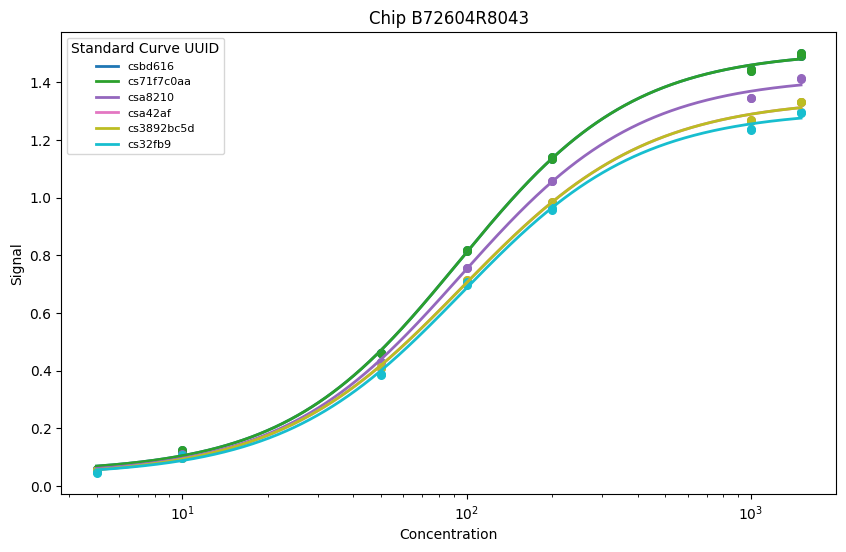

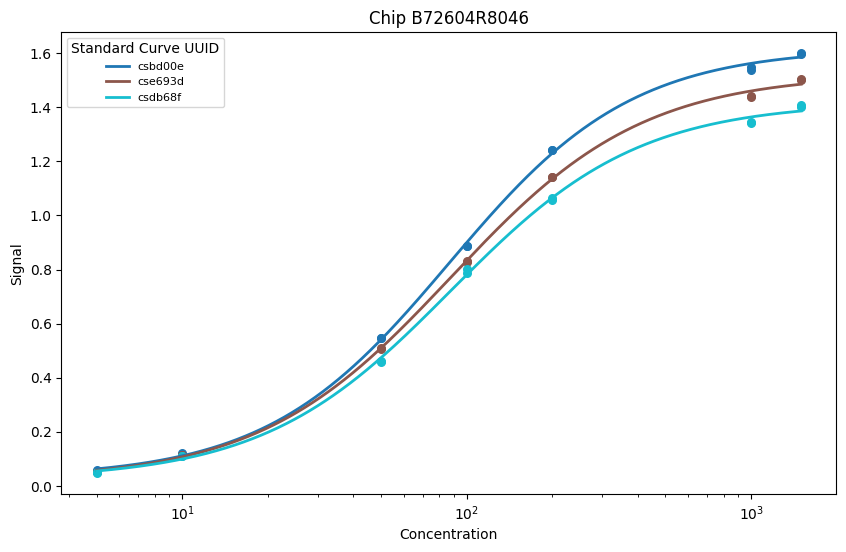

In [ ]:
for chip_id, data in bern_data.items():

    for file_name, df in data.items():

        if 'standard' in file_name:

            plt.figure(figsize=(10, 6))
            colours_mpl = plt.cm.tab10(np.linspace(0, 1, len(df)))
            
            fig = go.Figure()
            
            colours_plotly = pc.qualitative.Plotly 

            for i, (colour_mpl, row) in enumerate(zip(colours_mpl, df.itertuples())):
                
                x = parse_values(row.x_csv)
                y = parse_values(row.y_csv)
                x_fit = np.logspace(np.log10(min(x)), np.log10(max(x)), 1000)

                if row.fit_model == '5PL':
                    y_fit = five_pl(x_fit, row.a, row.d, row.c, row.b, row.e)
                else:
                    y_fit = four_pl(x_fit, row.a, row.d, row.c, row.b)
                
                uuid_str = str(row.standard_curve_uuid)

                plt.scatter(x, y, color=colour_mpl, s=30)
                plt.plot(x_fit, y_fit, color=colour_mpl, linewidth=2, label=uuid_str)
                
                colour_plotly = colours_plotly[i % len(colours_plotly)]
                
                fig.add_trace(go.Scatter(
                    x=x, y=y,
                    mode='markers',
                    marker=dict(color=colour_plotly, size=8),
                    name=f'{uuid_str} (Data)',
                    legendgroup=uuid_str,
                    showlegend=False,
                    hoverinfo='x+y'
                ))
                
                fig.add_trace(go.Scatter(
                    x=x_fit, y=y_fit,
                    mode='lines',
                    line=dict(color=colour_plotly, width=2),
                    name=uuid_str,
                    legendgroup=uuid_str,
                    hoverinfo='x+y+name'
                ))

            plt.xscale('log')
            plt.title(f'Chip {chip_id}')
            plt.xlabel('Concentration')
            plt.ylabel('Signal')
            plt.legend(title='Standard Curve UUID', fontsize=8)
            plt.show()
            
            fig.update_layout(
                title=f'Chip {chip_id}',
                xaxis_title='Concentration',
                yaxis_title='Signal',
                xaxis_type='log',
                legend_title='Standard Curve UUID',
                template='plotly_white'
            )
            
            fig.show()

            break

## $\color{yellow}{\text{Reading back Sensor reading}}$

In [63]:
def inverse_five_pl(y, a, d, c, b, e):
    
    try:
        ratio = (a - d) / (y - d)
        if ratio < 0:
            return np.nan
        
        inner = (ratio ** (1 / e)) - 1
        if inner < 0:
            return 0.0 
        
        return c * (inner ** (1 / b))
    
    except Exception:
        return np.nan

In [64]:
def inverse_four_pl(y, a, d, c, b):
    
    return inverse_five_pl(y, a, d, c, b, 1.0)

In [65]:
for chip_id, data in bern_data.items():
    
    df = next((file_df for file_name, file_df in data.items() if 'measurement-results' in file_name.lower()), None)
    
    if df is None or df.empty:
        continue
    
    df = df.sort_values(by=['Date', 'Time']).reset_index(drop=True)
    
    first_curve_uuid = df['Standard Curve UUID'].iloc[0]
    first_curve_row = df[df['Standard Curve UUID'] == first_curve_uuid].iloc[0]
    
    results = []

    for _, row in df.iterrows():
        
        signal = row['Signal']
        
        if pd.isna(signal):
            conc = np.nan
        elif first_curve_row['Standard Curve Fit Model'] == '5PL':
            conc = inverse_five_pl(signal, first_curve_row['Standard Curve A'], first_curve_row['Standard Curve D'], first_curve_row['Standard Curve C'], first_curve_row['Standard Curve B'], first_curve_row['Standard Curve E'])
        else:
            conc = inverse_four_pl(signal, first_curve_row['Standard Curve A'], first_curve_row['Standard Curve D'], first_curve_row['Standard Curve C'], first_curve_row['Standard Curve B'])

        results.append({
            'date': row['Date'],
            'time': row['Time'],
            'standard_curve_uuid': row['Standard Curve UUID'],
            'signal': signal,
            'concentration_measured_by_machine': row.get('Concentration Measured', np.nan),
            'concentration_on_first_curve': conc
        })

    results_df = pd.DataFrame(results)

    print(f'\nChip {chip_id} - Base Curve: {first_curve_uuid}')
    display(results_df)


Chip B72604R8043 - Base Curve: csbd616


,date,time,standard_curve_uuid,signal,concentration_measured_by_machine,concentration_on_first_curve
0,2026-07-21,12:31:56,csbd616,0.470746,66.638188,50.044016
1,2026-07-21,13:33:04,cs71f7c0aa,0.938090,128.687521,128.626848
2,2026-07-22,09:22:46,csa8210,0.660355,84.182945,74.813051
3,2026-07-22,09:37:53,csa8210,0.571505,68.221537,62.477250
4,2026-07-22,10:14:33,csa8210,0.627946,77.328345,70.134544
5,2026-07-22,10:29:39,csa8210,0.553468,65.543560,60.145865
6,2026-07-22,12:05:13,csa8210,0.267141,30.660839,27.845420
7,2026-07-22,12:49:04,csa8210,0.597099,75.271874,65.878010
8,2026-07-22,13:04:11,csa8210,0.491847,59.684416,52.537825
9,2026-07-23,08:34:12,csa42af,0.633546,84.998849,70.927122



Chip B72604R8046 - Base Curve: csbd00e


,date,time,standard_curve_uuid,signal,concentration_measured_by_machine,concentration_on_first_curve
0,2026-07-21,12:31:48,csbd00e,1.055461,135.318111,135.318107
1,2026-07-21,13:23:08,csbd00e,1.041719,131.608772,131.607299
2,2026-07-22,09:20:38,cse693d,0.617119,71.424062,58.522756
3,2026-07-22,09:35:32,cse693d,0.637778,66.565300,60.971615
4,2026-07-22,10:14:28,cse693d,0.737168,81.998760,73.806053
5,2026-07-22,10:29:20,cse693d,0.628262,65.220498,59.835327
6,2026-07-22,12:17:38,cse693d,0.309803,28.909628,27.755649
7,2026-07-22,12:49:33,cse693d,0.659227,77.481826,63.587026
8,2026-07-22,13:04:27,cse693d,0.554401,57.392091,51.467195
9,2026-07-23,08:32:20,csdb68f,0.716057,86.890595,70.917788
